In [1]:
##Need
##import file from computer
import os

# Create input directory
os.makedirs('/content/input', exist_ok=True)
os.makedirs('/content/output', exist_ok=True)

##mount google drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
#Need
##identify file
file = '/content/drive/MyDrive/JEB1433/ipcai_2020_full_res_data.h5'

In [3]:
##need
# Install core packages
import subprocess, sys

packages = [
    'diffdrr',
    'diffdrrdata',    # contains DeepFluoro + Ljubljana dataloaders
    'torch torchvision',
    'matplotlib seaborn',
    'numpy scipy',
    'h5py',
    'ipywidgets',
    'tqdm',
    'kornia',         # image similarity metrics (NCC, NMI)
    'einops',
    'pyvista',        # 3D volume visualization
    'torchio',        # medical image transforms
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkg.split())

print('\n✅ All packages installed!')

Installing diffdrr...
Installing diffdrrdata...
Installing torch torchvision...
Installing matplotlib seaborn...
Installing numpy scipy...
Installing h5py...
Installing ipywidgets...
Installing tqdm...
Installing kornia...
Installing einops...
Installing pyvista...
Installing torchio...

✅ All packages installed!


In [4]:
#Need
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Device selection: ---
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('🍎 Using Apple MPS (Metal) GPU acceleration')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🚀 Using CUDA GPU: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('💻 Using CPU (no GPU found — DRR will be slower but works fine)')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

🚀 Using CUDA GPU: Tesla T4
PyTorch version: 2.10.0+cu128
Device: cuda


In [5]:
##Need
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms
from pathlib import Path
import os

# Create the directory diffdrrdata expects
target_dir = Path("/root/user/diffdrr_data")
target_dir.mkdir(parents=True, exist_ok=True)

# Symlink your Drive file into that directory
drive_file = Path("/content/drive/MyDrive/JEB1433/ipcai_2020_full_res_data.h5")
target_file = target_dir / "ipcai_2020_full_res_data.h5"

if not target_file.exists():
    os.symlink(drive_file, target_file)
    print("✅ Symlinked Drive file")
else:
    print("✅ File already linked")

# Now load patient
SUBJECT_ID = 1
SUBSAMPLE   = 4 ##highest resolution

print(f'Loading DeepFluoro subject {SUBJECT_ID}...')
deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
print(f'✅ Loaded subject {SUBJECT_ID}')

✅ Symlinked Drive file
Loading DeepFluoro subject 1...
✅ Loaded subject 1


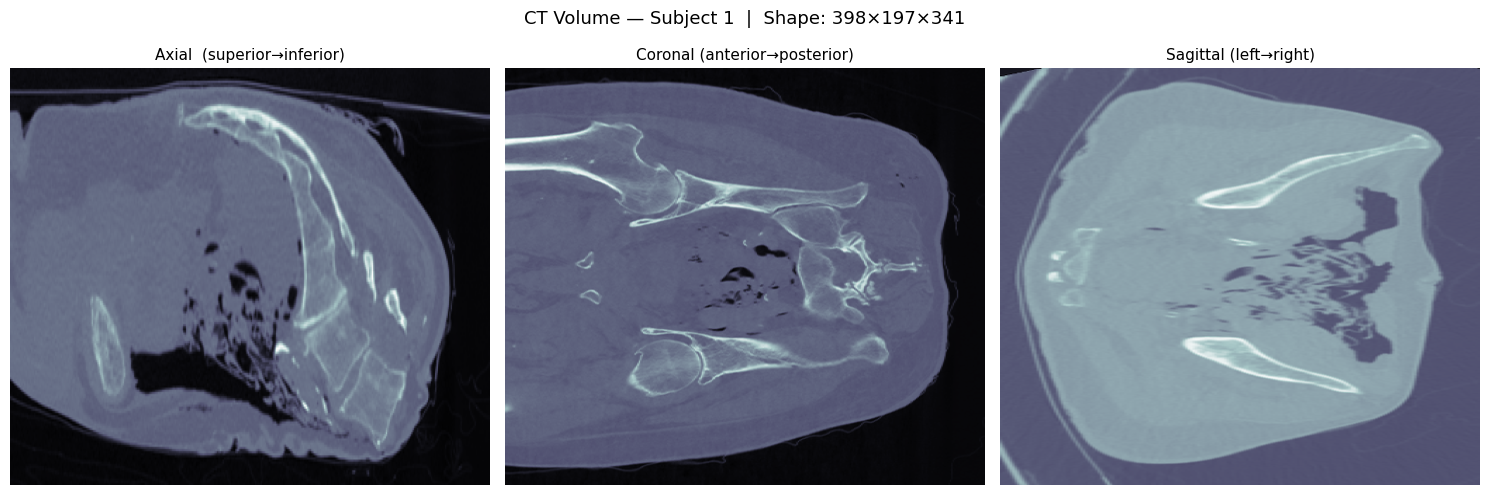

In [6]:
# Visualize orthogonal CT slices
# .data gives the raw tensor (C, D, H, W), then squeeze removes the channel dim
volume = deepfluoro.subject.volume.data.squeeze().numpy()  # (D, H, W)
D, H, W = volume.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'CT Volume — Subject {SUBJECT_ID}  |  Shape: {D}×{H}×{W}', fontsize=13)

slices = [
    (volume[D//2, :, :], 'Axial  (superior→inferior)'),
    (volume[:, H//2, :], 'Coronal (anterior→posterior)'),
    (volume[:, :, W//2], 'Sagittal (left→right)'),
]

for ax, (sl, title) in zip(axes, slices):
    ax.imshow(sl, cmap='bone', aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

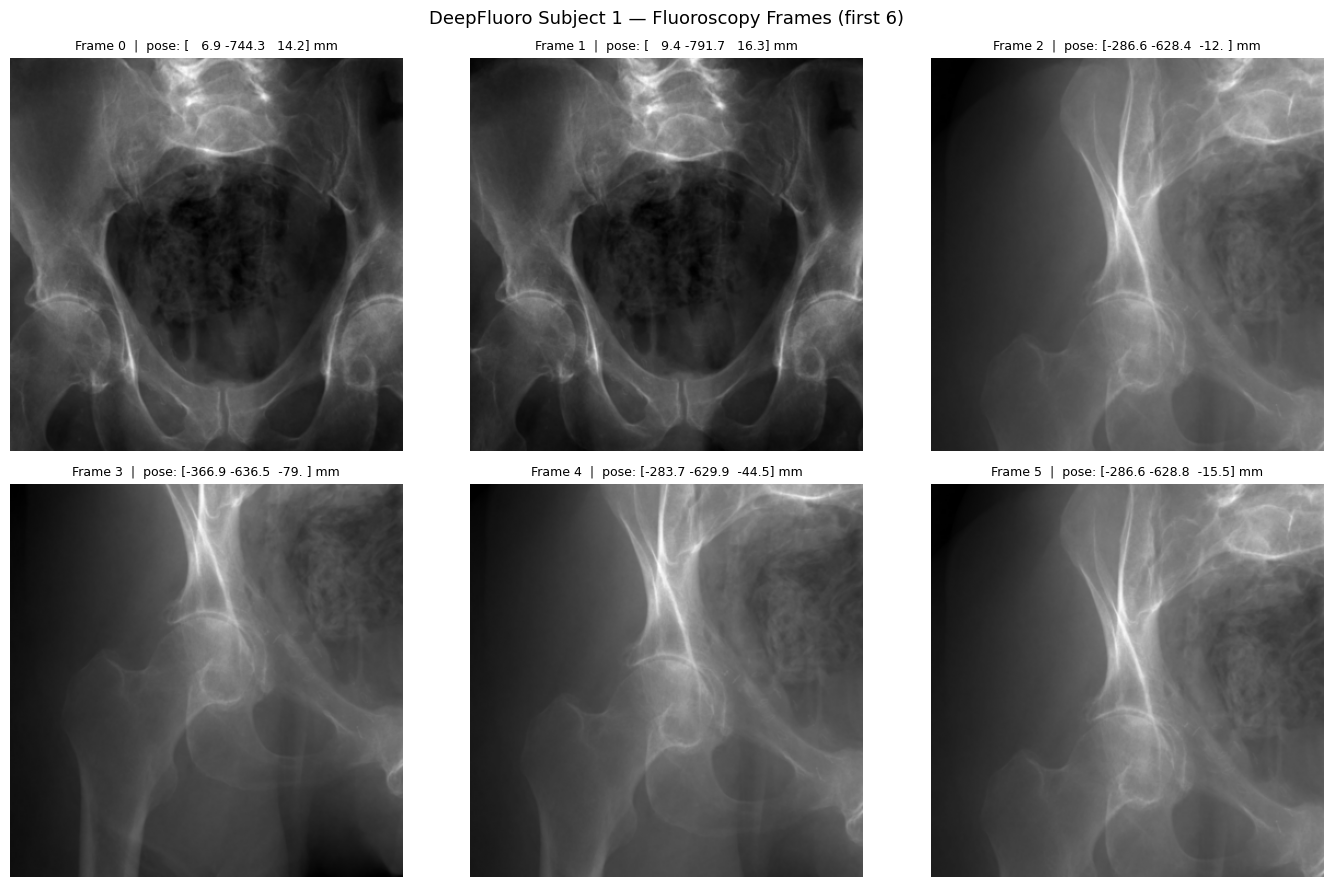

In [7]:
transform = Transforms(deepfluoro.height // SUBSAMPLE)

# Show first 6 fluoroscopy frames
n_show = min(6, len(deepfluoro))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f'DeepFluoro Subject {SUBJECT_ID} — Fluoroscopy Frames (first {n_show})', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue

    gt_img, pose = deepfluoro[i]
    gt_img = transform(gt_img)

    ax.imshow(gt_img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'Frame {i}  |  pose: {pose.matrix[0,:3,3].numpy().round(1)} mm', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
##Need
# Print ground truth pose for frame 0
gt_img, gt_pose = deepfluoro[0]

print('Ground truth pose (SE3 transformation matrix):')
print(gt_pose.matrix.squeeze().numpy().round(4))
print('Translation (x, y, z) in mm:', gt_pose.matrix[0, :3, 3].numpy().round(2))


Ground truth pose (SE3 transformation matrix):
[[ 9.974000e-01  6.000000e-04 -7.220000e-02  6.945400e+00]
 [ 2.100000e-03  9.993000e-01  3.630000e-02 -7.443021e+02]
 [ 7.210000e-02 -3.630000e-02  9.967000e-01  1.421940e+01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]
Translation (x, y, z) in mm: [   6.95 -744.3    14.22]


In [9]:
#Need
import json

config = {
    'subject_id': SUBJECT_ID,
    'subsample': SUBSAMPLE,
    'n_frames': len(deepfluoro),
    'ct_shape': list(deepfluoro.subject.volume.shape),
    'focal_len': float(deepfluoro.focal_len),
    'height': int(deepfluoro.height),
    'delx': float(deepfluoro.delx),
    'x0': float(deepfluoro.x0),
    'y0': float(deepfluoro.y0),
    'device': str(device),
}

with open('/content/output/dataset_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Config saved to outputs/dataset_config.json')
print(json.dumps(config, indent=2))

✅ Config saved to outputs/dataset_config.json
{
  "subject_id": 1,
  "subsample": 4,
  "n_frames": 111,
  "ct_shape": [
    1,
    398,
    197,
    341
  ],
  "focal_len": 1020.0,
  "height": 1436,
  "delx": 0.1940000057220459,
  "x0": -0.09700000286102295,
  "y0": -0.09700000286102295,
  "device": "cuda"
}


In [10]:
##load config and ensure cuda
import torch
import numpy as np
import matplotlib.pyplot as plt
import time, json
from tqdm import tqdm

from diffdrr.drr import DRR
from diffdrr.visualization import plot_drr
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms

# Load config
with open('/content/output/dataset_config.json') as f:
    cfg = json.load(f)

SUBJECT_ID = cfg['subject_id']
SUBSAMPLE  = cfg['subsample']

# Device
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

# Load dataset
deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)
print(f'✅ Dataset loaded: {len(deepfluoro)} fluoroscopy frames')

Device: cuda
✅ Dataset loaded: 111 fluoroscopy frames


In [11]:
# Initialize DRR renderer matching the C-arm fluoroscope geometry
drr = DRR(
    deepfluoro.subject,                  # CT volume (TorchIO Subject)
    sdd=deepfluoro.focal_len,            # Source-to-detector distance [mm]
    height=deepfluoro.height // SUBSAMPLE,  # Detector height [px]
    delx=deepfluoro.delx * SUBSAMPLE,    # Pixel spacing [mm]
    x0=deepfluoro.x0,                    # Principal point x offset [mm]
    y0=deepfluoro.y0,                    # Principal point y offset [mm]
).to(device)

print('DiffDRR renderer initialized!')
print(f'  Source-to-detector distance: {deepfluoro.focal_len:.1f} mm')
print(f'  Detector size:  {deepfluoro.height // SUBSAMPLE} × {deepfluoro.height // SUBSAMPLE} px')
print(f'  Pixel spacing:  {deepfluoro.delx * SUBSAMPLE:.3f} mm')
print(f'  Principal pt:   ({deepfluoro.x0:.2f}, {deepfluoro.y0:.2f}) mm')

DiffDRR renderer initialized!
  Source-to-detector distance: 1020.0 mm
  Detector size:  359 × 359 px
  Pixel spacing:  0.776 mm
  Principal pt:   (-0.10, -0.10) mm


In [12]:
# Render DRR at ground truth pose for frame 0
frame_idx = 0
gt_img, gt_pose = deepfluoro[frame_idx]

# Move pose to device
gt_pose_dev = gt_pose.to(device)

# Render — this is the DiffDRR forward pass (Siddon's method as tensor ops)
with torch.no_grad():
    drr_img = drr(gt_pose_dev)

# Apply same intensity normalization as the real fluoroscopy
gt_img_t  = transform(gt_img)
drr_img_t = transform(drr_img.cpu())

print(f'DRR rendered: shape = {drr_img_t.shape}')
print(f'GT fluoroscopy: shape = {gt_img_t.shape}')

DRR rendered: shape = torch.Size([1, 1, 359, 359])
GT fluoroscopy: shape = torch.Size([1, 1, 359, 359])


In [13]:
## benchmark rendering speed
def benchmark_drr(subject, focal_len, pixel_spacing, resolution, pose, device, n_reps=5):
    """Benchmark DRR rendering at a given resolution."""
    renderer = DRR(
        subject,
        sdd=focal_len,
        height=resolution,
        delx=pixel_spacing,
    ).to(device)

    p = pose.to(device)

    # Warmup
    with torch.no_grad():
        _ = renderer(p)
    if device.type == 'mps':
        torch.mps.synchronize()
    elif device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        with torch.no_grad():
            _ = renderer(p)
        if device.type == 'mps':
            torch.mps.synchronize()
        elif device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    return np.mean(times), np.std(times)


_, gt_pose = deepfluoro[0]
resolutions = [64, 128, 256, 512]
results = {}

print(f'Benchmarking DiffDRR on {device}...')
print(f'{"Resolution":>12}  {"Mean (s)":>10}  {"Std (s)":>8}')
print('-' * 35)

for res in resolutions:
    mean_t, std_t = benchmark_drr(
        deepfluoro.subject,
        deepfluoro.focal_len,
        deepfluoro.delx,
        res, gt_pose, device
    )
    results[res] = (mean_t, std_t)
    print(f'{res:>6}×{res:<6}  {mean_t:>10.4f}  {std_t:>8.4f}')

print('\n(Freund 2004 ray casting: 512×512 took 27–52 seconds on 2GHz Pentium IV)')
print('(DiffDRR on GPU: sub-second, thanks to vectorized Siddon + hardware acceleration)')

Benchmarking DiffDRR on cuda...
  Resolution    Mean (s)   Std (s)
-----------------------------------
    64×64          0.0079    0.0001
   128×128         0.0277    0.0004
   256×256         0.0795    0.0019
   512×512         0.3081    0.0005

(Freund 2004 ray casting: 512×512 took 27–52 seconds on 2GHz Pentium IV)
(DiffDRR on GPU: sub-second, thanks to vectorized Siddon + hardware acceleration)


In [12]:
##function for calculating ncc values
def ncc(img1, img2):
    """Normalized Cross-Correlation between two images."""
    a = img1.flatten() - img1.mean()
    b = img2.flatten() - img2.mean()
    return (a * b).sum() / (torch.norm(a) * torch.norm(b) + 1e-8)


ncc_values = []
print(f'Computing NCC for all {len(deepfluoro)} frames...')

for i in tqdm(range(len(deepfluoro))):
    gt_img, gt_pose = deepfluoro[i]
    with torch.no_grad():
        rendered = drr(gt_pose.to(device)).cpu()

    gt_t  = transform(gt_img)
    drr_t = transform(rendered)

    ncc_val = ncc(gt_t, drr_t).item()
    ncc_values.append(ncc_val)

ncc_arr = np.array(ncc_values)

##print results
print(f'\nNCC Statistics (Real Fluoroscopy vs DiffDRR at GT Pose):')
print(f'  Mean:    {ncc_arr.mean():.5f}')
print(f'  Std:     {ncc_arr.std():.5f}')
print(f'  Min:     {ncc_arr.min():.5f}')
print(f'  Max:     {ncc_arr.max():.5f}')

Computing NCC for all 111 frames...


100%|██████████| 111/111 [00:39<00:00,  2.78it/s]


NCC Statistics (Real Fluoroscopy vs DiffDRR at GT Pose):
  Mean:    0.89616
  Std:     0.05248
  Min:     0.51656
  Max:     0.95516


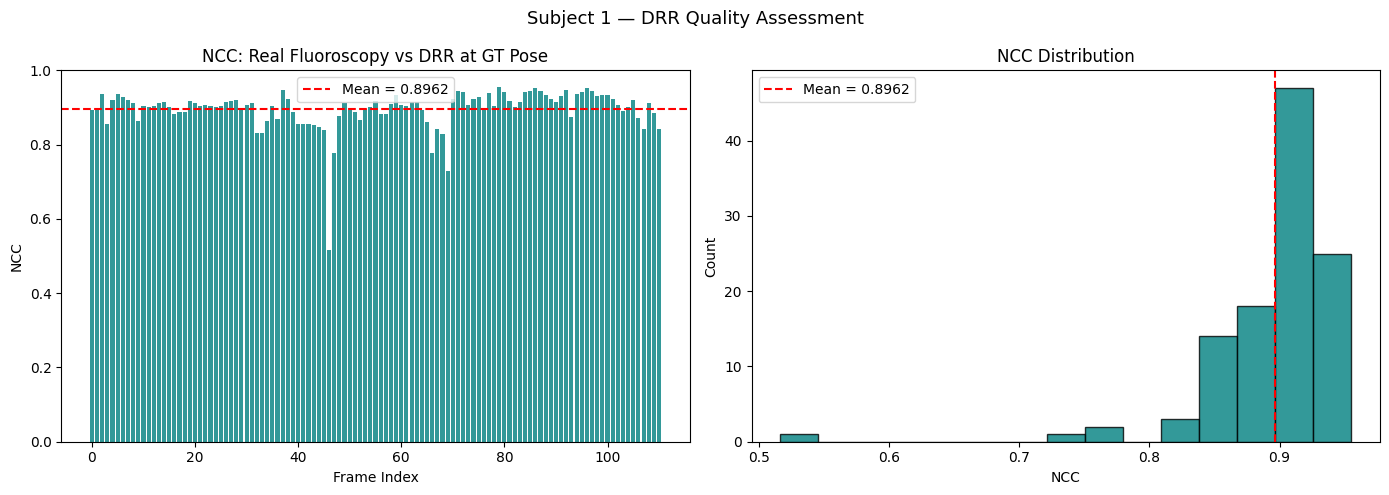

Saved: ncc_analysis.png, ncc_values.npy


In [18]:
# Plot NCC across frames
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(ncc_values)), ncc_values, color='teal', alpha=0.8)
axes[0].axhline(ncc_arr.mean(), color='red', linestyle='--', label=f'Mean = {ncc_arr.mean():.4f}')
axes[0].set_xlabel('Frame Index')
axes[0].set_ylabel('NCC')
axes[0].set_title('NCC: Real Fluoroscopy vs DRR at GT Pose')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].hist(ncc_values, bins=15, color='teal', alpha=0.8, edgecolor='black')
axes[1].axvline(ncc_arr.mean(), color='red', linestyle='--', label=f'Mean = {ncc_arr.mean():.4f}')
axes[1].set_xlabel('NCC')
axes[1].set_ylabel('Count')
axes[1].set_title('NCC Distribution')
axes[1].legend()

plt.suptitle(f'Subject {SUBJECT_ID} — DRR Quality Assessment', fontsize=13)
plt.tight_layout()
plt.savefig('/content/output/ncc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save NCC results
np.save('/content/output/ncc_values.npy', ncc_arr)
print('Saved: ncc_analysis.png, ncc_values.npy')

In [19]:
# Save benchmark results
import json

benchmark_results = {str(res): results[res] for res in results}
with open('/content/output/benchmark_results.json', 'w') as f:
    json.dump(benchmark_results, f, indent=2)
print('Saved benchmark_results.json')

Saved benchmark_results.json


In [13]:
##Load in specific frame
##Need
##load all the information for pertubation
with open('/content/output/dataset_config.json') as f:
    cfg = json.load(f)

SUBJECT_ID = cfg['subject_id']
SUBSAMPLE  = cfg['subsample']
FRAME_IDX  = 20

deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
transform  = Transforms(deepfluoro.height // SUBSAMPLE)

drr = DRR(
    deepfluoro.subject,
    sdd=deepfluoro.focal_len,
    height=deepfluoro.height // SUBSAMPLE,
    delx=deepfluoro.delx * SUBSAMPLE,
    x0=deepfluoro.x0,
    y0=deepfluoro.y0,
).to(device)

gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_mat = gt_pose.matrix[0].numpy()

print(f'✅ Ready — Subject {SUBJECT_ID}, Frame {FRAME_IDX}')

✅ Ready — Subject 1, Frame 20


In [14]:
#Need
### setup the pose optimizer function
import torch.nn as nn
from diffdrr.drr import DRR
from diffdrr.metrics import NormalizedCrossCorrelation2d
from diffdrr.pose import RigidTransform
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms

class PoseOptimizer(nn.Module):
    def __init__(self, initial_pose):
        super().__init__()
        mat = initial_pose.matrix[0]
        self.log_rot = nn.Parameter(self._log_SO3(mat[:3,:3]).clone().detach())
        self.trans   = nn.Parameter(mat[:3,3].clone().detach())

    @staticmethod
    def _log_SO3(R):
        theta = torch.acos(((R.trace()-1)/2).clamp(-1+1e-6, 1-1e-6))
        if theta.abs() < 1e-6: return torch.zeros(3)
        return (theta/(2*torch.sin(theta))) * torch.stack([
            R[2,1]-R[1,2], R[0,2]-R[2,0], R[1,0]-R[0,1]
        ])

    @staticmethod
    def _exp_SO3(v):
        theta = v.norm()
        if theta < 1e-6:
            return torch.eye(3, device=v.device)
        k = v / theta
        K = torch.zeros(3, 3, device=v.device)
        K[0,1],K[0,2] = -k[2], k[1]
        K[1,0],K[1,2] =  k[2],-k[0]
        K[2,0],K[2,1] = -k[1], k[0]
        return torch.eye(3, device=v.device) + torch.sin(theta)*K + (1-torch.cos(theta))*(K@K)
    def get_pose(self):
        R = self._exp_SO3(self.log_rot)
        mat = torch.eye(4, device=self.log_rot.device)
        mat[:3,:3] = R
        mat[:3, 3] = self.trans
        return RigidTransform(mat.unsqueeze(0))  # ← wrap in RigidTransform and add batch dim

def make_translation_perturbation(gt_pose, dx=0, dy=0, dz=0):
    """Perturb in the camera's local frame, not world frame."""
    mat = gt_pose.matrix.clone()
    delta = torch.tensor([dx, dy, dz], dtype=torch.float32, device=mat.device)
    # Rotate delta into world frame using the current rotation
    R = mat[0, :3, :3]
    mat[0, :3, 3] += R @ delta
    return RigidTransform(mat)


def make_rotation_perturbation(gt_pose, rx_deg=0, ry_deg=0, rz_deg=0):
    """Perturb only rotation, keep translation exactly at GT."""
    mat = gt_pose.matrix.clone()
    rx, ry, rz = [torch.deg2rad(torch.tensor(a, dtype=torch.float32))
                  for a in (rx_deg, ry_deg, rz_deg)]
    cx,cy,cz = torch.cos(rx),torch.cos(ry),torch.cos(rz)
    sx,sy,sz = torch.sin(rx),torch.sin(ry),torch.sin(rz)
    Rx = torch.tensor([[1,0,0],[0,cx,-sx],[0,sx,cx]])
    Ry = torch.tensor([[cy,0,sy],[0,1,0],[-sy,0,cy]])
    Rz = torch.tensor([[cz,-sz,0],[sz,cz,0],[0,0,1]])
    dR = (Rz @ Ry @ Rx).float().to(mat.device)
    mat[0, :3, :3] = dR @ mat[0, :3, :3]
    return RigidTransform(mat)


def run_registration(gt_img, gt_pose, init_pose, n_iter=200):
    """Run Adam registration, return history and final pose."""
    target   = transform(gt_img).to(device)
    ncc_fn   = NormalizedCrossCorrelation2d(patch_size=9)
    pose_opt = PoseOptimizer(init_pose.to(device)).to(device)

    optimizer = torch.optim.Adam([
        {'params': pose_opt.log_rot, 'lr': 1e-3},
        {'params': pose_opt.trans,   'lr': 1.0},
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_iter, eta_min=1e-5)

    history = {'ncc': [], 'trans_err': [], 'rot_err': [],
               'trans_x': [], 'trans_y': [], 'trans_z': []}

    for i in range(n_iter):
        optimizer.zero_grad()
        rendered_t = transform(drr(pose_opt.get_pose()))
        loss = -ncc_fn(rendered_t.to(device), target)
        loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            cur_mat   = pose_opt.get_pose().matrix[0].detach().cpu().numpy()
            trans_err = np.linalg.norm(cur_mat[:3,3] - gt_mat[:3,3])
            rot_mat   = cur_mat[:3,:3] @ gt_mat[:3,:3].T
            rot_err   = np.degrees(np.arccos(np.clip((np.trace(rot_mat)-1)/2, -1, 1)))
            # Per-axis translation error
            per_axis  = cur_mat[:3,3] - gt_mat[:3,3]
            history['ncc'].append(-loss.item())
            history['trans_err'].append(float(trans_err))
            history['rot_err'].append(float(rot_err))
            history['trans_x'].append(float(abs(per_axis[0])))
            history['trans_y'].append(float(abs(per_axis[1])))
            history['trans_z'].append(float(abs(per_axis[2])))

    return history, pose_opt.get_pose()


print('✅ Classes and functions defined')

✅ Classes and functions defined


Translation experiment

In [34]:
# Three seeds = three magnitudes along different axes
# Rotation is held exactly at GT — only translation varies
# Reload GT
gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_mat = gt_pose.matrix[0].cpu().numpy()

print("GT translation:", gt_mat[:3, 3])
print("GT rotation:\n", gt_mat[:3, :3].round(4))

trans_experiments = {
    'In-plane X (±10mm)':  make_translation_perturbation(gt_pose, dx=-10, dy=0,  dz=0),
    'In-plane Y (±10mm)':  make_translation_perturbation(gt_pose, dx=0,  dy=-10, dz=0),
    'Depth Z (±10mm)':     make_translation_perturbation(gt_pose, dx=0,  dy=0,  dz=-10),
}

# Verify the perturbation is clean
for name, pose in trans_experiments.items():
    delta = pose.matrix[0, :3, 3].cpu().numpy() - gt_mat[:3, 3]
    print(f"{name}: delta = {delta.round(2)}")
# SEEDS = [1, 10, 100]
TRANS_MAG = -10.0  # mm — max per axis

# trans_experiments = {}
# for seed in SEEDS:
#     torch.manual_seed(seed)
#     dt = torch.FloatTensor(3).uniform_(-TRANS_MAG, TRANS_MAG)
#     trans_experiments[f'Seed {seed} (Δ={dt.numpy().round(1)})'] = \
#         make_translation_perturbation(gt_pose, dx=dt[0].item(), dy=dt[1].item(), dz=dt[2].item())


trans_histories = {}
trans_poses     = {}

print('Experiment 1.1: Translation-only perturbations')
print('Rotation held at GT — isolating translation recovery\n')

for name, init_pose in trans_experiments.items():
    init_t = init_pose.matrix[0, :3, 3].cpu().numpy()
    init_err = np.linalg.norm(init_t - gt_mat[:3, 3])
    print(f'  {name}  |  initial error: {init_err:.2f} mm')
    h, final = run_registration(gt_img, gt_pose, init_pose, n_iter=200)
    trans_histories[name] = h
    trans_poses[name]     = final
    print(f'  → final trans: {h["trans_err"][-1]:.2f} mm  |  '
          f'rot: {h["rot_err"][-1]:.2f}°  |  NCC: {h["ncc"][-1]:.4f}\n')

print('✅ Translation experiment complete')

GT translation: [ -12.5061035 -793.04315     -8.529358 ]
GT rotation:
 [[ 0.9965  0.0152 -0.082 ]
 [-0.0115  0.9989  0.0453]
 [ 0.0826 -0.0442  0.9956]]
In-plane X (±10mm): delta = [-9.97  0.11 -0.83]
In-plane Y (±10mm): delta = [-0.15 -9.99  0.44]
Depth Z (±10mm): delta = [ 0.82 -0.45 -9.96]
Experiment 1.1: Translation-only perturbations
Rotation held at GT — isolating translation recovery

  In-plane X (±10mm)  |  initial error: 10.00 mm
  → final trans: 4.10 mm  |  rot: 0.33°  |  NCC: 0.6243

  In-plane Y (±10mm)  |  initial error: 10.00 mm
  → final trans: 1.76 mm  |  rot: 0.15°  |  NCC: 0.6240

  Depth Z (±10mm)  |  initial error: 10.00 mm
  → final trans: 3.91 mm  |  rot: 0.23°  |  NCC: 0.6194

✅ Translation experiment complete


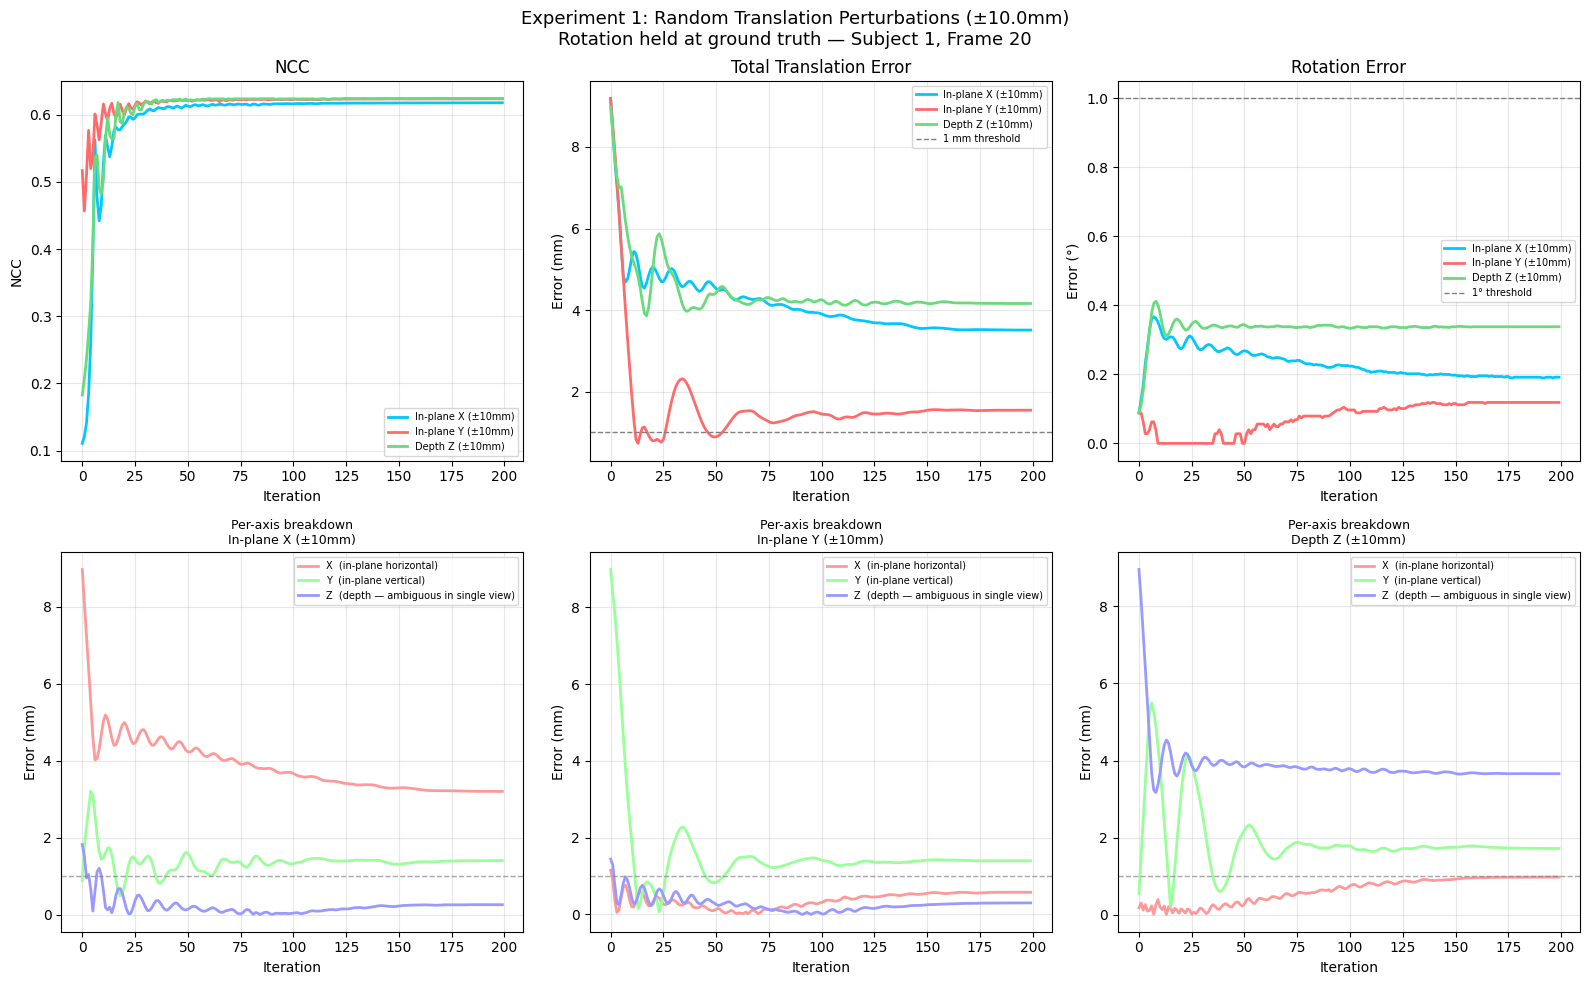

Saved: experiment_translation.png


In [63]:
##plot translation
TRANS_MAG = 10.0  # mm — max per axis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Experiment 1: Random Translation Perturbations (±{TRANS_MAG}mm)\n'
             f'Rotation held at ground truth — Subject {SUBJECT_ID}, Frame {FRAME_IDX}',
             fontsize=13)

colors = ['#00c8ff', '#ff6b6b', '#69db7c']
iters  = range(200)

# ── Row 1: Standard convergence curves ────────────────────────────────────────
for (name, h), col in zip(trans_histories.items(), colors):
    axes[0,0].plot(h['ncc'],       color=col, lw=2, label=name)
    axes[0,1].plot(h['trans_err'], color=col, lw=2, label=name)
    axes[0,2].plot(h['rot_err'],   color=col, lw=2, label=name)

axes[0,0].set_title('NCC')
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('NCC')

axes[0,1].set_title('Total Translation Error')
axes[0,1].set_xlabel('Iteration')
axes[0,1].set_ylabel('Error (mm)')
axes[0,1].axhline(1.0, color='gray', ls='--', lw=1, label='1 mm threshold')

axes[0,2].set_title('Rotation Error')
axes[0,2].set_xlabel('Iteration')
axes[0,2].set_ylabel('Error (°)')
axes[0,2].axhline(1.0, color='gray', ls='--', lw=1, label='1° threshold')

for ax in axes[0]:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# ── Row 2: Per-axis translation breakdown ─────────────────────────────────────
axis_colors = {'X': '#ff9999', 'Y': '#99ff99', 'Z': '#9999ff'}
axis_labels = {'X': 'X  (in-plane horizontal)',
               'Y': 'Y  (in-plane vertical)',
               'Z': 'Z  (depth — ambiguous in single view)'}

for col_idx, (name, h) in enumerate(trans_histories.items()):
    ax = axes[1, col_idx]
    ax.plot(h['trans_x'], color=axis_colors['X'], lw=2, label=axis_labels['X'])
    ax.plot(h['trans_y'], color=axis_colors['Y'], lw=2, label=axis_labels['Y'])
    ax.plot(h['trans_z'], color=axis_colors['Z'], lw=2, label=axis_labels['Z'])
    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'Per-axis breakdown\n{name}', fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Error (mm)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/output/experiment_translation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: experiment_translation.png')

In [15]:
##clear GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()
print(f'GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB')

GPU memory free: 15.09 GB


Rotation experiment


In [32]:
# Three seeds = three magnitudes along different axes
# Translation held-only rotation

gt_img, gt_pose = deepfluoro[FRAME_IDX]
gt_mat = gt_pose.matrix[0].cpu().numpy()

print("GT translation:", gt_mat[:3, 3])
print("GT rotation:\n", gt_mat[:3, :3].round(4))

##radians to degrees
# Rad = 0.3
# deg = 180/((np.pi) * Rad)
deg = -5.0
print(f'Each axis rotated by: {deg} degrees')

##run rotation experiments
rot_experiments = {
    'Roll X':  make_rotation_perturbation(gt_pose, rx_deg=deg,  ry_deg=0, rz_deg=0),
    'Pitch Y': make_rotation_perturbation(gt_pose, rx_deg=0,  ry_deg=deg, rz_deg=0),
    'Yaw Z':   make_rotation_perturbation(gt_pose, rx_deg=0,  ry_deg=0, rz_deg=deg),
}

# Verify the perturbation is clean
for name, pose in rot_experiments.items():
    delta = pose.matrix[0, :3, 3].cpu().numpy() - gt_mat[:3, 3]
    print(f"{name}: delta = {delta.round(2)}")
# SEEDS = [1, 10, 100]
TRANS_MAG = 10.0  # mm — max per axis

# trans_experiments = {}
# for seed in SEEDS:
#     torch.manual_seed(seed)
#     dt = torch.FloatTensor(3).uniform_(-TRANS_MAG, TRANS_MAG)
#     trans_experiments[f'Seed {seed} (Δ={dt.numpy().round(1)})'] = \
#         make_translation_perturbation(gt_pose, dx=dt[0].item(), dy=dt[1].item(), dz=dt[2].item())


rot_histories = {}
rot_poses     = {}

print('Experiment 1.2: Rotation-only perturbations')
print('Translation held at GT — isolating rotation recovery\n')

for name, init_pose in rot_experiments.items():
    init_r    = init_pose.matrix[0, :3, :3].cpu().numpy()
    rot_m     = init_r @ gt_mat[:3, :3].T
    init_rot  = np.degrees(np.arccos(np.clip((np.trace(rot_m)-1)/2, -1, 1)))
    print(f'  {name}  |  initial rot error: {init_rot:.2f}°')
    h, final = run_registration(gt_img, gt_pose, init_pose, n_iter=200)
    rot_histories[name] = h
    rot_poses[name]     = final
    print(f'  → final trans: {h["trans_err"][-1]:.2f} mm  |  '
          f'rot: {h["rot_err"][-1]:.2f}°  |  NCC: {h["ncc"][-1]:.4f}\n')

print('✅ Rotation experiment complete')

GT translation: [ -12.5061035 -793.04315     -8.529358 ]
GT rotation:
 [[ 0.9965  0.0152 -0.082 ]
 [-0.0115  0.9989  0.0453]
 [ 0.0826 -0.0442  0.9956]]
Each axis rotated by: -5.0 degrees
Roll X: delta = [0. 0. 0.]
Pitch Y: delta = [0. 0. 0.]
Yaw Z: delta = [0. 0. 0.]
Experiment 1.2: Rotation-only perturbations
Translation held at GT — isolating rotation recovery

  Roll X  |  initial rot error: 5.00°
  → final trans: 70.96 mm  |  rot: 4.32°  |  NCC: 0.1431

  Pitch Y  |  initial rot error: 5.00°
  → final trans: 1.46 mm  |  rot: 0.10°  |  NCC: 0.6231

  Yaw Z  |  initial rot error: 5.00°
  → final trans: 14.52 mm  |  rot: 5.17°  |  NCC: 0.0846

✅ Rotation experiment complete


In [ ]:
##clear GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()
print(f'GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB')

In [16]:
###multi seed and iteration block components
def perturb_pose(pose, rot_deg=5.0, trans_mm=10.0):
    mat = pose.matrix.clone()

    r = torch.deg2rad(torch.FloatTensor(3).uniform_(-rot_deg, rot_deg))
    cx, cy, cz = torch.cos(r)
    sx, sy, sz = torch.sin(r)
    Rx = torch.tensor([[1,0,0],[0,cx,-sx],[0,sx,cx]])
    Ry = torch.tensor([[cy,0,sy],[0,1,0],[-sy,0,cy]])
    Rz = torch.tensor([[cz,-sz,0],[sz,cz,0],[0,0,1]])
    dR = (Rz @ Ry @ Rx).float()
    dt = torch.FloatTensor(3).uniform_(-trans_mm, trans_mm)

    mat[0, :3, :3] = dR @ mat[0, :3, :3]
    mat[0, :3,  3] = mat[0, :3, 3] + dt

    return RigidTransform(mat)

In [29]:
##loops for multi seed and iteration testing
# Run registration for 3 different perturbation seeds on the same frame

SUBJECTS = [2,3,4,5,6]
SEEDS       = [1, 2, 3, 10, 50]
N_ITER      = [100, 200, 500]
ROT_PERTURB = 5.0
TRANS_PERTURB = 10.0
FRAME_IDX = 20

all_histories  = {}
all_poses      = {}
all_rendered   = {}
all_pose_mats  = {}

for subject_id in SUBJECTS:
    print(f'\n{"="*55}')
    print(f'SUBJECT {subject_id}')
    print(f'{"="*55}')

    # Load new subject
    deepfluoro = DeepFluoroDataset(id_number=subject_id)
    transform  = Transforms(deepfluoro.height // SUBSAMPLE)

    drr = DRR(
        deepfluoro.subject,
        sdd=deepfluoro.focal_len,
        height=deepfluoro.height // SUBSAMPLE,
        delx=deepfluoro.delx * SUBSAMPLE,
        x0=deepfluoro.x0,
        y0=deepfluoro.y0,
    ).to(device)

    gt_img, gt_pose = deepfluoro[FRAME_IDX]
    gt_mat = gt_pose.matrix[0].cpu().numpy()

    ##loop for iterations
    for it in N_ITER:
        ##loop for seeds
        for seed in SEEDS:

            print(f'\n── Seed {seed} ──────────────────────────')
            torch.manual_seed(seed)

            ##initialization
            init_pose = perturb_pose(gt_pose, rot_deg=ROT_PERTURB, trans_mm=TRANS_PERTURB)
            init_t    = init_pose.matrix[0, :3, 3].numpy()
            gt_t      = gt_pose.matrix[0, :3, 3].numpy()
            print(f'  Initial trans error: {np.linalg.norm(gt_t - init_t):.2f} mm')

            ##setup
            target   = transform(gt_img).to(device)
            ncc_fn   = NormalizedCrossCorrelation2d(patch_size=9)
            pose_opt = PoseOptimizer(init_pose.to(device)).to(device)

            #Adam optimizer
            optimizer = torch.optim.Adam([
                {'params': pose_opt.log_rot, 'lr': 1e-3},
                {'params': pose_opt.trans,   'lr': 1.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=it, eta_min=1e-5)

            ##get GT
            gt_mat  = gt_pose.matrix[0].numpy()
            history = {'ncc': [], 'trans_err': [], 'rot_err': []}

            ##run iterations
            for i in tqdm(range(it), desc=f'Seed {seed}'):
                optimizer.zero_grad()
                pose       = pose_opt.get_pose()
                rendered_t = transform(drr(pose))
                loss       = -ncc_fn(rendered_t.to(device), target)
                loss.backward()
                optimizer.step()
                scheduler.step()

                with torch.no_grad():
                    cur_mat   = pose_opt.get_pose().matrix[0].detach().cpu().numpy()
                    trans_err = np.linalg.norm(cur_mat[:3,3] - gt_mat[:3,3])
                    rot_mat   = cur_mat[:3,:3] @ gt_mat[:3,:3].T
                    rot_err   = np.degrees(np.arccos(np.clip((np.trace(rot_mat)-1)/2, -1, 1)))
                    history['ncc'].append(-loss.item())
                    history['trans_err'].append(float(trans_err))
                    history['rot_err'].append(float(rot_err))

            ##update with seed and iteration
            all_histories[(seed, it, subject_id)]  = history
            all_poses[(seed, it, subject_id)]      = pose_opt.get_pose()

            print(f'  Final trans error: {history["trans_err"][-1]:.2f} mm')
            print(f'  Final rot error:   {history["rot_err"][-1]:.2f}°')
            print(f'  Final NCC:         {history["ncc"][-1]:.5f}')

            ##clear cache
            torch.cuda.empty_cache()
            gc.collect()
    print(f'\n── Completed all seeds for N_ITER={it} ──────────────────────────')
# Save all results
np.save('../outputs/all_histories_multisubject.npy', all_histories)
print('\n✅ All subjects complete — results saved')


SUBJECT 2

── Seed 1 ──────────────────────────
  Initial trans error: 12.11 mm


Seed 1: 100%|██████████| 100/100 [00:36<00:00,  2.71it/s]


  Final trans error: 29.49 mm
  Final rot error:   2.13°
  Final NCC:         0.53520

── Seed 2 ──────────────────────────
  Initial trans error: 4.92 mm


Seed 2: 100%|██████████| 100/100 [00:36<00:00,  2.74it/s]


  Final trans error: 17.06 mm
  Final rot error:   1.00°
  Final NCC:         0.65074

── Seed 3 ──────────────────────────
  Initial trans error: 12.93 mm


...

Seed 10: 100%|██████████| 500/500 [03:02<00:00,  2.74it/s]


  Final trans error: 4.99 mm
  Final rot error:   0.49°
  Final NCC:         0.65825

── Seed 50 ──────────────────────────
  Initial trans error: 11.79 mm


Seed 50: 100%|██████████| 500/500 [03:02<00:00,  2.74it/s]


  Final trans error: 4.79 mm
  Final rot error:   0.33°
  Final NCC:         0.66766

── Completed all seeds for N_ITER=500 ──────────────────────────

SUBJECT 3


KeyboardInterrupt: 

In [ ]:
###plot results
iter_colors = {100: '#ff6b6b', 200: '#00c8ff', 500: '#69db7c'}
seed_styles = {1: '-', 2: '--', 3: ':', 10: '-.', 50: (0,(3,1,1,1))}

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig, axes = plt.plot(figsize=(18, 5))
fig.suptitle(f'Registration Convergence — {len(SEEDS)} Seeds × {len(N_ITER)} Iteration Counts\n'
             f'Subject {SUBJECT_ID}, Frame {FRAME_IDX} | '
             f'Perturbation: ±{ROT_PERTURB}° / ±{TRANS_PERTURB}mm', fontsize=12)

for (seed, it, subject_id), h in all_histories.items():

    iters = range(len(h['ncc']))
    col   = iter_colors[it]
    ls    = seed_styles[seed]
    lbl   = f'S{seed}/N{it}'
    axes[0].plot(iters, h['ncc'],       color=col, ls=ls, lw=1.5, alpha=0.8, label=lbl)
    axes[1].plot(iters, h['trans_err'], color=col, ls=ls, lw=1.5, alpha=0.8, label=lbl)
    axes[2].plot(iters, h['rot_err'],   color=col, ls=ls, lw=1.5, alpha=0.8, label=lbl)

axes[0].set_title('NCC (↑ better)');            axes[0].set_ylabel('NCC')
axes[1].set_title('Translation Error (↓)');     axes[1].set_ylabel('mm')
axes[2].set_title('Rotation Error (↓)');        axes[2].set_ylabel('degrees')

axes[1].axhline(1.0, color='white', ls='--', lw=1, alpha=0.4, label='1mm')
axes[2].axhline(1.0, color='white', ls='--', lw=1, alpha=0.4, label='1°')

for ax in axes:
    ax.set_xlabel('Iteration')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
# plt.savefig('/content/outputs/multi_seed_iter_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

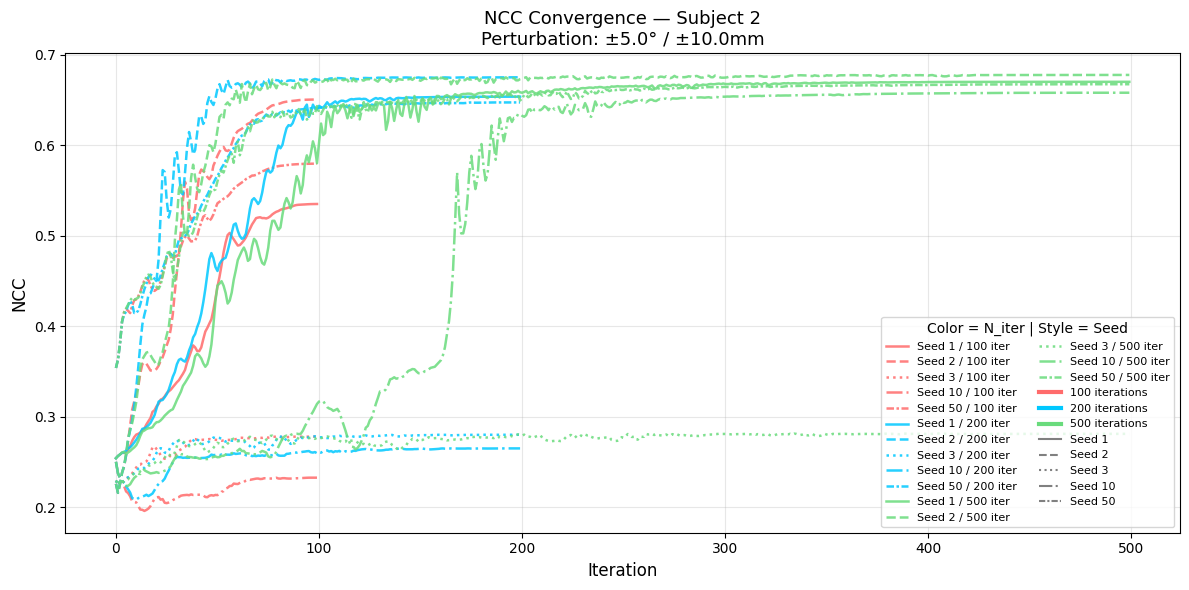

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

iter_colors = {100: '#ff6b6b', 200: '#00c8ff', 500: '#69db7c'}
seed_styles = {1: '-', 2: '--', 3: ':', 10: '-.', 50: (0,(3,1,1,1))}

TARGET_SUBJECT = 2

for (seed, it, subject_id), h in all_histories.items():
    if subject_id != TARGET_SUBJECT:
        continue
    iters = range(len(h['ncc']))
    ax.plot(iters, h['ncc'],
            color=iter_colors[it],
            ls=seed_styles[seed],
            lw=1.8, alpha=0.85,
            label=f'Seed {seed} / {it} iter')

# Legend — split into two groups for readability
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('NCC', fontsize=12)
ax.set_title(f'NCC Convergence — Subject {TARGET_SUBJECT}\n'
             f'Perturbation: ±{ROT_PERTURB}° / ±{TRANS_PERTURB}mm',
             fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=3, loc='lower right')

# Add color legend for N_ITER
for it, col in iter_colors.items():
    ax.plot([], [], color=col, lw=3, label=f'{it} iterations')
for seed, ls in seed_styles.items():
    ax.plot([], [], color='gray', ls=ls, lw=1.5, label=f'Seed {seed}')

ax.legend(fontsize=8, ncol=2, loc='lower right',
          title='Color = N_iter | Style = Seed')

plt.tight_layout()
# plt.savefig(f'./outputs/ncc_subject{TARGET_SUBJECT}.png', dpi=150, bbox_inches='tight')
plt.show()